In [1]:
# importing packages
import matplotlib.pyplot as plt
import ptitprince as pt
import random
import numpy as np
import pandas as pd
import json
from tqdm import tqdm
from scipy import stats
import seaborn as sns
import networkx as nx
import pickle
import itertools
from dotmotif import Motif, GrandIsoExecutor
from scipy.stats import kruskal, f_oneway, levene, ranksums, ttest_ind, wilcoxon, norm, chi2_contingency, chisquare
from statsmodels.stats.multitest import multipletests
from sklearn import mixture
from scipy.interpolate import interp1d
from tabulate import tabulate
from statannotations.Annotator import Annotator

plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (10,10)
sns.set_theme(style="whitegrid")
random.seed(747)

# Import Stefan's Library for Data Management of V1DD
from lsmm_data import LSMMData

In [2]:
# Set-Wise Comparison Functions: Determining the intersection of assembly assignment of two pyramidal cells 
# These comparison functions map to C in the statistical methods section.
def shared(pre, post, A):
    try:
        return not A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def disjoint(pre, post, A):
    try:
        return A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def shared_a(pre, post, A):
    return (pre not in no_A) and (post not in no_A) # type: ignore

def shared_no_a(pre, post, A):
    return (pre in no_A) and (post in no_A) # type: ignore

def no_a_a(pre, post, A):
    return (pre in no_A) and (post not in no_A) # type: ignore

def a_no_a(pre, post, A):
    return (pre not in no_A) and (post in no_A) # type: ignore

def no_a_to_any(pre, _, A):
    return (pre in no_A) # type: ignore

def a_to_any(pre, _, A):
    return (pre not in no_A) # type: ignore

comparison_functions = [shared, disjoint, shared_a, shared_no_a, no_a_a, a_no_a, no_a_to_any, a_to_any]
groups = ['shared', 'disjoint', 'shared_a', 'shared_no_a']

In [3]:
# Pull Data from LSMM Data
with open('pyr_cells_rectangular_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to pyramidal cells only
459


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\lsmm_data\LSMMData.py:391: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['connectome_index'] = data['structural']['post_cell'].index
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\lsmm_data\LSMMData.py:417: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['pt_position'] = [[data['structural']['post_cell'].iloc[i]['pt_position_x'],data['structural']['post_cell'].iloc[i]['pt_position

Generating Connectome...


100%|██████████| 44293/44293 [02:04<00:00, 356.22it/s]


Generating Connectome...


100%|██████████| 44293/44293 [01:59<00:00, 370.96it/s]


In [4]:
### Pull necessary data from V1DD using LSMMData Manager
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index
post_cell_table = data_a['structural']['post_cell'].copy()
post_cell_table['connectome_index'] = post_cell_table.index
synapse_table = data_a['structural']['synapse']

# Establish seperate sets for the pre and post synaptic partnes
# This is necessary as the set of connectome index of pre-synaptic cells do not 
# match the post-synaptic cells due to allowing unproofread post-synaptic targets.
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()

no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']

pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))
# Each cell has a distinct root id, so it is unnecessary to establish different sets
assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df['size'] = synapses_df['size'] * (9 * 9 * 45) / (10**9) # Voxels -> Cubic micrometers

# Filter cell tables to only assembly cells
cell_table = cell_table[cell_table['pt_root_id'].isin(assembly_root_ids_set)]
post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

# Finalized set of Root IDs, which are 
pre_root_ids = set(cell_table['pt_root_id'].values)
post_root_ids = set(post_cell_table['pt_root_id'].values)
all_root_ids = pre_root_ids | post_root_ids

In [5]:
### Prep the sets for Analysis, following our description in the Methods section
# Collect our connectomes of pre and post synaptic sets based on the root_ids of the neurons
w = {}
s = {}
b = {}
for pre in pre_root_ids:
    for post in post_root_ids:
        if pre != post:
            w[(pre, post)] = 0
            s[(pre, post)] = 0
            b[(pre, post)] = 0

for i, row in synapses_df.iterrows():
    pre = row['pre_pt_root_id']
    post = row['post_pt_root_id']
    w[(pre, post)] += row['size']
    s[(pre, post)] += 1
    b[(pre, post)] = 1

# Split out assemblies and no_a
assembly_names = set(assembly_to_root_ids.keys()) - set(['No A'])
A_invert = {assembly: set(assembly_to_root_ids[assembly]) for assembly in assembly_names}
no_A = set(assembly_to_root_ids['No A'])
all_coregistered_root_ids = mappings_a['assemblies_by_pt_root_id'].keys()
assembly_root_ids_excluding_no_A = set(all_coregistered_root_ids) - no_A
A = {pt_root_id: set(mappings_a['assemblies_by_pt_root_id'][pt_root_id]) for pt_root_id in all_root_ids if 'No A' not in mappings_a['assemblies_by_pt_root_id'][pt_root_id]}

In [6]:
S_nonzero_pairwise = {}
W_nonzero_pairwise = {}
B_pairwise = {}
for connection_type in comparison_functions:
    S_nonzero_pairwise[connection_type.__name__] = {}
    W_nonzero_pairwise[connection_type.__name__] = {}
    B_pairwise[connection_type.__name__] = {}
    for (j, i) in w.keys():
        if connection_type(j, i, A):
            B_pairwise[connection_type.__name__][(j, i)] = 1 if w[(j, i)] > 0 else 0
            if w[(j, i)] > 0:
                S_nonzero_pairwise[connection_type.__name__][(j, i)] = s[(j, i)]
                W_nonzero_pairwise[connection_type.__name__][(j, i)] = w[(j, i)]

S_nonzero_out = {}
W_nonzero_out = {}
for connection_type in comparison_functions:
    S_nonzero_out[connection_type.__name__] = {}
    W_nonzero_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0]) > 0:
            S_nonzero_out[connection_type.__name__][j] = sum([s[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])
            W_nonzero_out[connection_type.__name__][j] = sum([w[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])

S_nonzero_in = {}
W_nonzero_in = {}
for connection_type in comparison_functions:
    S_nonzero_in[connection_type.__name__] = {}
    W_nonzero_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A)]) > 0 and len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0]):
            S_nonzero_in[connection_type.__name__][i] = sum([s[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])
            W_nonzero_in[connection_type.__name__][i] = sum([w[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])

In [17]:
def save_figure(figure_name):
    plt.savefig(
        f"./draft_figures/{figure_name}.png",
        dpi=500,
        bbox_inches="tight")
    
def plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val, save=False, figure_name=None):
    """
    Plots a raincloud plot for two connection type groups, with sample sizes in the y-axis labels.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """
    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Data frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Set up the plot
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="whitegrid")

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,  
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  
        alpha=0.8,  
        move=0.25,
        point_size = 6,  
        orient="v" 
    )

    # Set markings for significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=30)
    annot.annotate()

    # Add plot title and labels
    plt.title(title, size=30)
    plt.xlabel("Connection Type", size=26)
    plt.ylabel(y_lab, size=26)
    plt.xticks(fontsize = 26)
    plt.yticks(fontsize = 26)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()
    plt.close()

def plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, 
                                           y_lab, p_val, for_chains = True,
                                           save=False, figure_name=None
):
    """
    Plots a raincloud plot comparing connection types, 
    plus a smaller side subplot summarizing mean ± SEM for each group.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """

    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Build a frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Compute the statistics for the side plot
    # (Assuming values > 0 for simplicity; modify if needed.)
    shared_log = np.log10(shared_values)
    disjoint_log = np.log10(disjoint_values)

    mean_shared_log = np.mean(shared_log)
    mean_disjoint_log = np.mean(disjoint_log)
    sem_shared_log = stats.sem(shared_log, ddof=1) if n_shared > 1 else 0
    sem_disjoint_log = stats.sem(disjoint_log, ddof=1) if n_disjoint > 1 else 0

    # Set up a figure with two subplots
    fig = plt.figure(figsize=(15, 10))
    # Allocate 2 columns with a narrower column on the right
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)
    
    # Set up styling
    ax_main = fig.add_subplot(gs[0])
    ax_side = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # --- Main plot (original RainCloud) ---
    pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,
        alpha=0.8,
        move=0.25,
        point_size=6,
        orient="v",
        ax=ax_main
    )

    # Annotate significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax_main, 
                      pairs,
                      data=data,
                      x="Group",
                      y="Values",
                      order=y_labels # Force the order
                      )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=28)
    annot.annotate()

    # Axis title and labels
    ax_main.set_title(title, size=24)
    ax_main.set_xlabel("Connection Type", size=24)
    ax_main.set_ylabel(y_lab, size=24)
    ax_main.tick_params(labelsize=24)
    ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax_main.yaxis.get_offset_text().set_fontsize(24)


    # --- Side plot (Mean ± SEM of log(data))---
    # Currently place two horizontal lines and use fill_between for each ± sem region.

    x_vals = [1, 2]  # x positions for shared and disjoint
    mean_logs = [mean_shared_log, mean_disjoint_log]
    sem_logs = [sem_shared_log, sem_disjoint_log]
    colors = [(0.4, 0.6, 0.8, 0.8), 'grey']

    for i, x in enumerate(x_vals):
        m_log = mean_logs[i]
        s_log = sem_logs[i]
        c = colors[i]

        # Horizontal line for mean
        ax_side.hlines(
            y = m_log, 
            xmin = x - 0.15, 
            xmax = x + 0.15, 
            color = c, 
            linewidth = 3
        )
        # Shaded area for ± SEM
        ax_side.fill_betweenx(
            y = [m_log - s_log, m_log + s_log],
            x1 = x - 0.15,
            x2 = x + 0.15,
            color = c,
            alpha = 0.4
        )

    # Tidy up side axis
    ax_side.set_title("Mean ± SEM", size=24)
    ax_side.set_xlim(0.5, 2.5)  
    ax_side.set_xticks(x_vals)
    ax_side.set_xticklabels(["Shared", "Disjoint"], fontsize=24)
    ax_side.tick_params(axis='y', labelsize=24)
    # Show that y-values are on a log base 10 scale
    if for_chains:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight Products) $(\mathrm{\mu m^6})$", size=24)
    else:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight) $(\mathrm{\mu m^3})$", size=24)

    if save and figure_name is not None:
        save_figure(figure_name + "_with_side_plot")

    plt.tight_layout()
    plt.show()
    plt.close()

def synaptic_count_histogram(values_dict, connection_type, save=False, figure_name=None):
    """
    Plots a histogram of synaptic counts for a given connection type, using integer bins,
    with frequency labels on each bar.

    Parameters:
    - values_dict: dict of {(pre, post): count} pairs
    - connection_type: str, e.g., 'shared', 'disjoint', etc.
    - save: bool, whether to save the figure
    - figure_name: str, path to save the figure if save is True
    """
    values = list(values_dict.values())
    if not values:
        print(f"No values to plot for connection type: {connection_type}")
        return

    max_val = max(values)
    bins = range(0, max_val + 2)  # +2 to include max_val itself as upper bound

    plt.figure(figsize=(8, 6))
    counts, bins, patches = plt.hist(values, bins=bins, color='purple', edgecolor='gold', align='left')

    plt.title(f'Histogram of Synaptic Counts for "{connection_type}" Connections')
    plt.xlabel('Synaptic Count')
    plt.ylabel('Frequency')
    plt.xticks(bins)  # show every integer tick
    plt.xlim(left=0, right=max_val + 1)

    # Add frequency labels on top of each bar
    for bin_edge, count in zip(bins, counts):
        if count > 0:
            plt.text(bin_edge, count + 0.5, str(int(count)), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    # if save and figure_name is not None:
    #     save_figure(figure_name)

    plt.show()
    plt.close()

def ranksum_signedrank_two_group_comparison(comparison_dict, aggregation_method="by connection", directionality=None, data_type="binary", 
                            paired=False, non_zero=False, chain_test = False, chain_description = "Excitatory", save=True, figure_name=None):
    """
    Compares 'shared' and 'disjoint' groups based on connection type and data type.
    Uses a one-sided Wilcoxon rank-sum test and performs a Wilcoxon signed-rank test if paired=True.

    Parameters:
    - comparison_dict (dict): Dictionary with 'shared' and 'disjoint' data.
    - aggregation_method (str): Type of connection ('connection' for pairwise, 'cell' for inbound/outbound by cell).
    - directionality (str): Direction of connectivity for 'cell' type ('inbound' or 'outbound').
    - data_type (str): Data type ('binary' for connectivity, 'synaptic_count' for synaptic counts, 'summed_psd' for nonzero PSD).
    - paired (bool): If True, performs an additional Wilcoxon signed-rank test on paired data.
    - non_zero (bool): If True, filters out zero entries for summed PSD.
    - chain_test (bool): If True, the test is considering chains.
    - chain_description (str): Type of intermediate cell in chain ('excitatory' or 'inhibitory')
    """

    # Set title and labels based on connection_type and data_type
    if aggregation_method == "connection":  # Pairwise connections
        if data_type == "binary":
            title = "Binary Connectivity"
            y_lab = "Binary Connections"
            folder = "pairwise_binary_connectivity"
        elif data_type == "synaptic_count":
            if non_zero == True:
                title = "Synaptic Counts"
                y_lab = "Nonzero Synaptic Count"
                folder = 'synaptic_count'
        elif data_type == "summed_psd":
            if non_zero == True:
                title = "Synaptic Weight"
                y_lab = "Nonzero Synaptic Weight (\u03bcm$^3$)"
                # title = "Nonzero Summed PSD"
                # y_lab = "Nonzero Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_nonzero_summed_psd"
            else:
                title = "Synaptic Weight"
                y_lab = "Synaptic Weight (\u03bcm$^3$)"
                # title = "Summed PSD"
                # y_lab = "Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_summed_psd"
        else:
            raise ValueError("Invalid data_type for pairwise connection.")

    elif aggregation_method == "cell":  # By cell with inbound/outbound directionality
        if directionality not in ["inbound", "outbound"]:
            raise ValueError("For 'cell' connection_type, directionality must be 'inbound' or 'outbound'.")
        
        if data_type == "binary":
            title = f"Probability of {directionality.capitalize()} Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Connection"
            folder = f"{directionality}_connection_probability"
        elif data_type == "synaptic_count":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Count by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Count"
            folder = f"{directionality}_average_nonzero_synaptic_count"
        elif data_type == "summed_psd":
            title = f"Average Nonzero {directionality.capitalize()} PSD by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} PSD (\u03bcm$^3$)"
            folder = f"{directionality}_average_nonzero_psd"
        else:
            raise ValueError("Invalid data_type for inbound/outbound connection.")
    else:
        raise ValueError("Invalid connection_type. Must be 'connection' or 'cell'.")

    if chain_test:
        if directionality == None:
            title = f"{chain_description} Chain Weight Proucts"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'binary':
            title = f"Probability of {directionality.capitalize()} Chain Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Chain Connection"
        elif data_type == 'summed_psd':
            title = f"Average Nonzero {directionality.capitalize()} PSD Chain Product by Cell"
            y_lab = "Synaptic Weight Products"

    shared_values = np.array(list(comparison_dict["shared"].values()))
    disjoint_values = np.array(list(comparison_dict["disjoint"].values()))
    # Filter out zeros if non_zero is specified for summed_psd
    if non_zero and (data_type == "summed_psd" or data_type == 'synaptic_count'):
        shared_values = shared_values[shared_values != 0]
        disjoint_values = disjoint_values[disjoint_values != 0]

    # Perform the Wilcoxon rank-sum test (one-sided, shared > disjoint)
    if chain_description=='Inhibitory':
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='less')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
    else:
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='greater')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")

    title = f'{title}\nRank-Sum P-value: {rank_sum_p:.2g}'

    # If paired=True, also perform a Wilcoxon signed-rank test on paired observations
    if paired:
        shared_keys = set(comparison_dict.get('shared', {}).keys())
        disjoint_keys = set(comparison_dict.get('disjoint', {}).keys())
        common_keys = shared_keys & disjoint_keys

        if common_keys:
            # Extract paired data for common keys
            shared_paired = np.array([comparison_dict["shared"][key] for key in common_keys])
            disjoint_paired = np.array([comparison_dict["disjoint"][key] for key in common_keys])

            # Perform Wilcoxon signed-rank test on paired data
            if chain_description=='Inhibitory':
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='less')
                print(f"Wilcoxon Signed-Rank Test (paired, shared < disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
            else:
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='greater')
                print(f"Wilcoxon Signed-Rank Test (paired, shared > disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")

            title = f'{title}, Signed-Rank P-value: {signed_rank_p:.2g}'
        else:
            print("No common observations found for paired analysis.")

    plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, figure_name=figure_name)
    for_chains = True if chain_test else False
    plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, for_chains = for_chains, figure_name=figure_name)

# Histograms

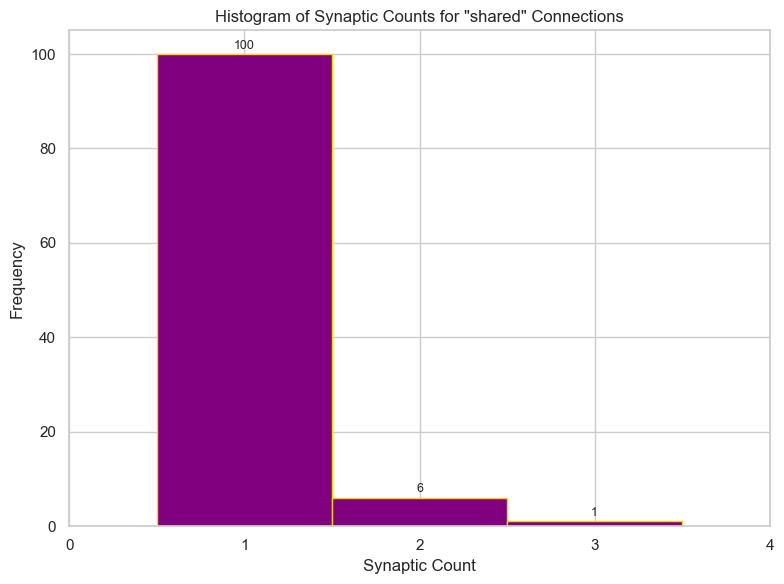

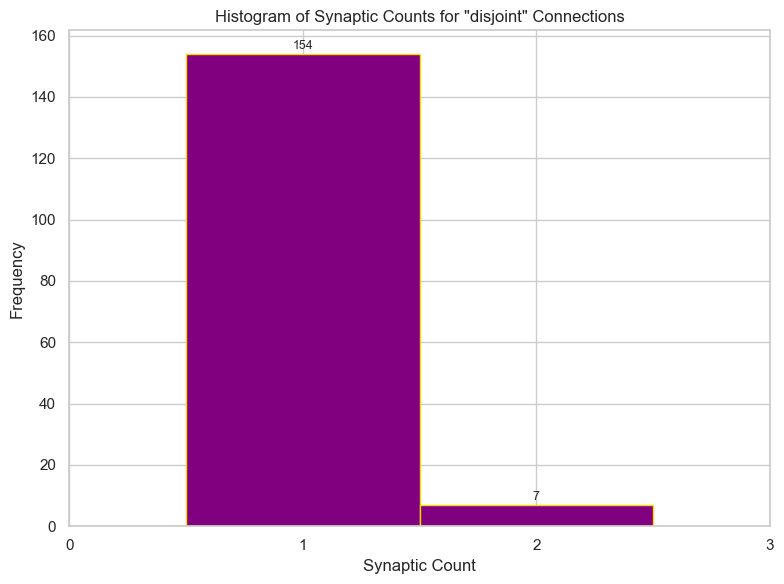

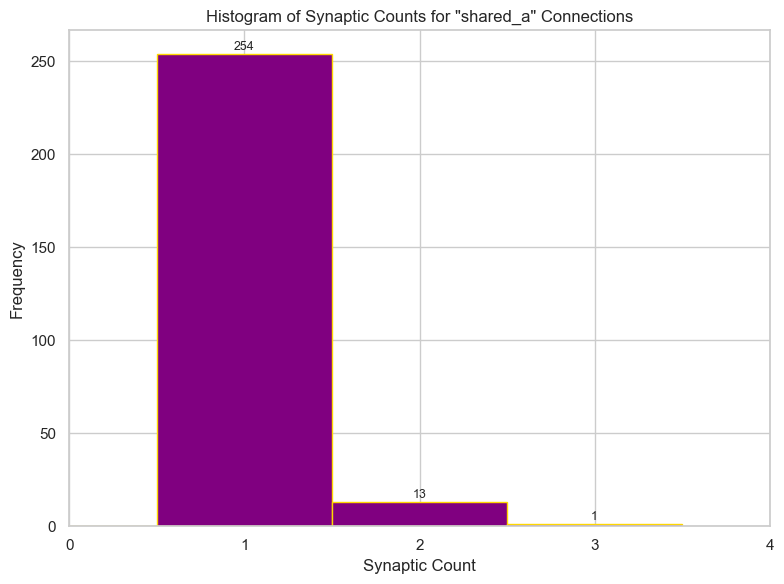

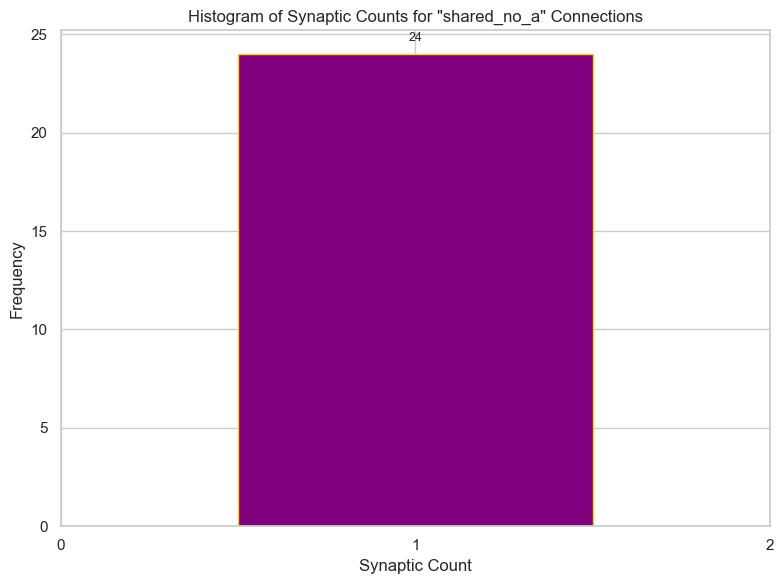

In [8]:
for group in groups:
    synaptic_count_histogram(
        values_dict=S_nonzero_pairwise[group],
        connection_type=group,
        save=False,
        figure_name=None
    )

# Analysis

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3098, P-value: 0.3784
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


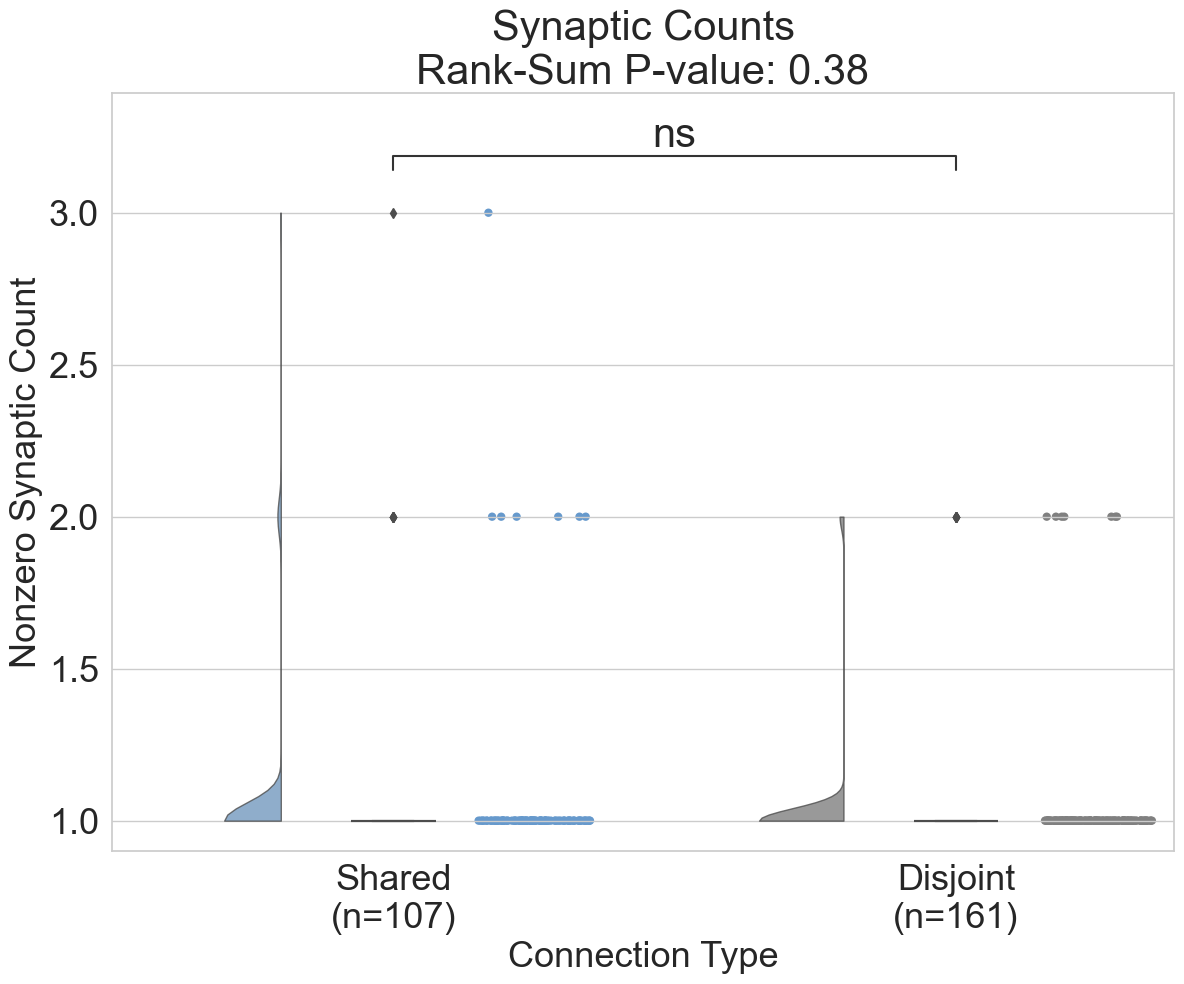

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_8148\3462587406.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


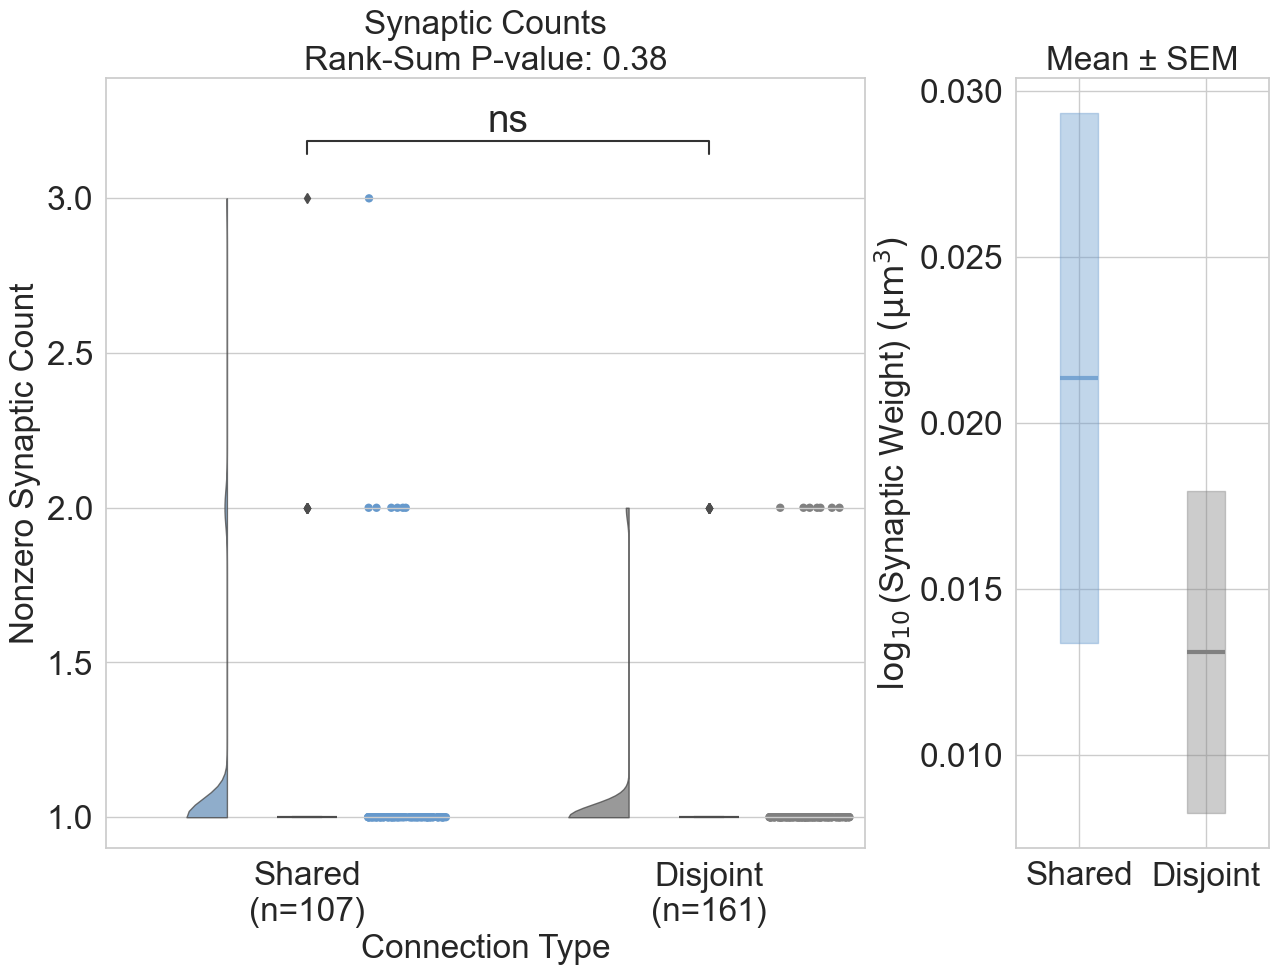

In [18]:
ranksum_signedrank_two_group_comparison(S_nonzero_pairwise,
                                        aggregation_method='connection',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3555, P-value: 0.3611
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 17.5, P-value: 0.2767
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:3.611e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


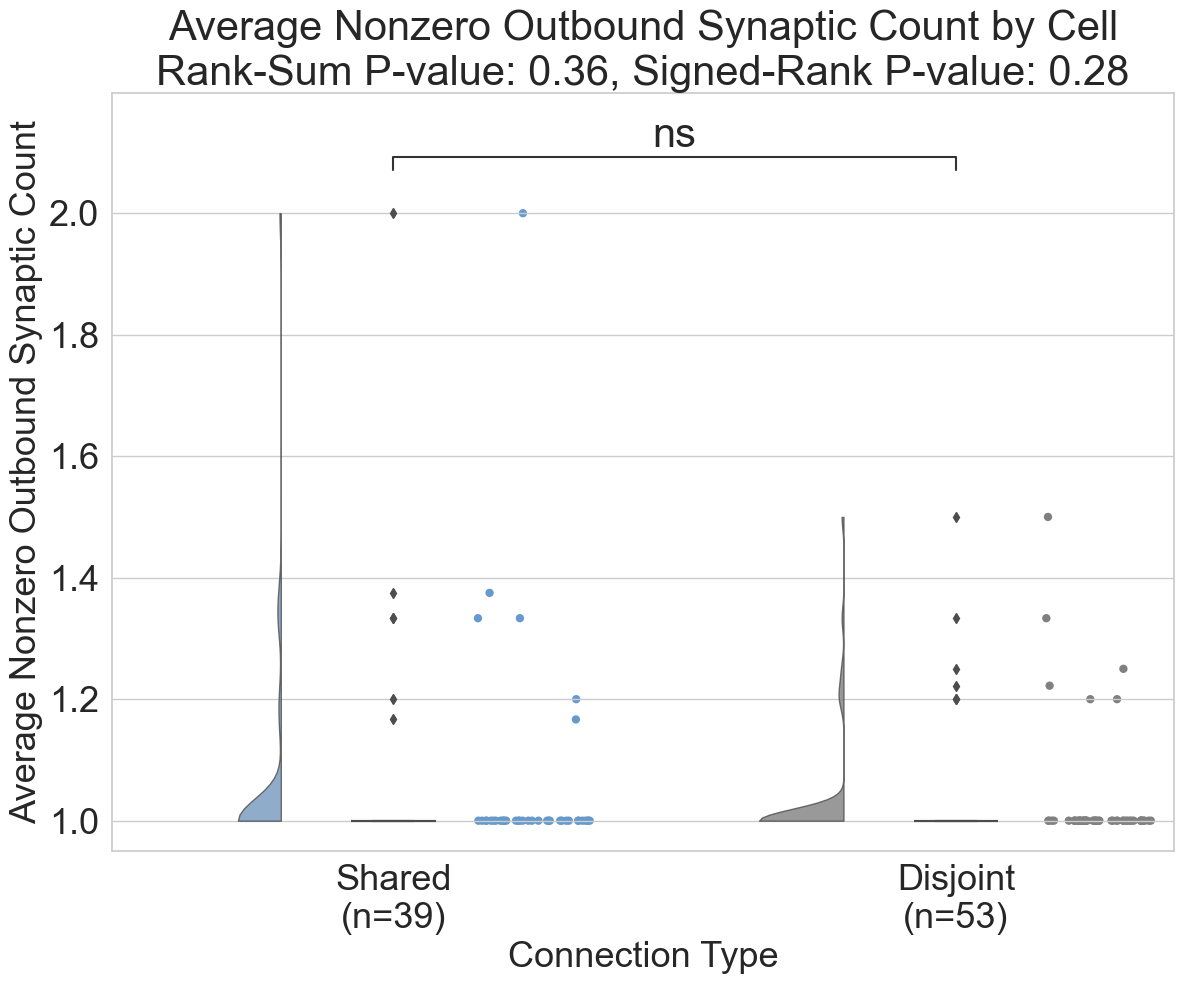

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_8148\3462587406.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:3.611e-01


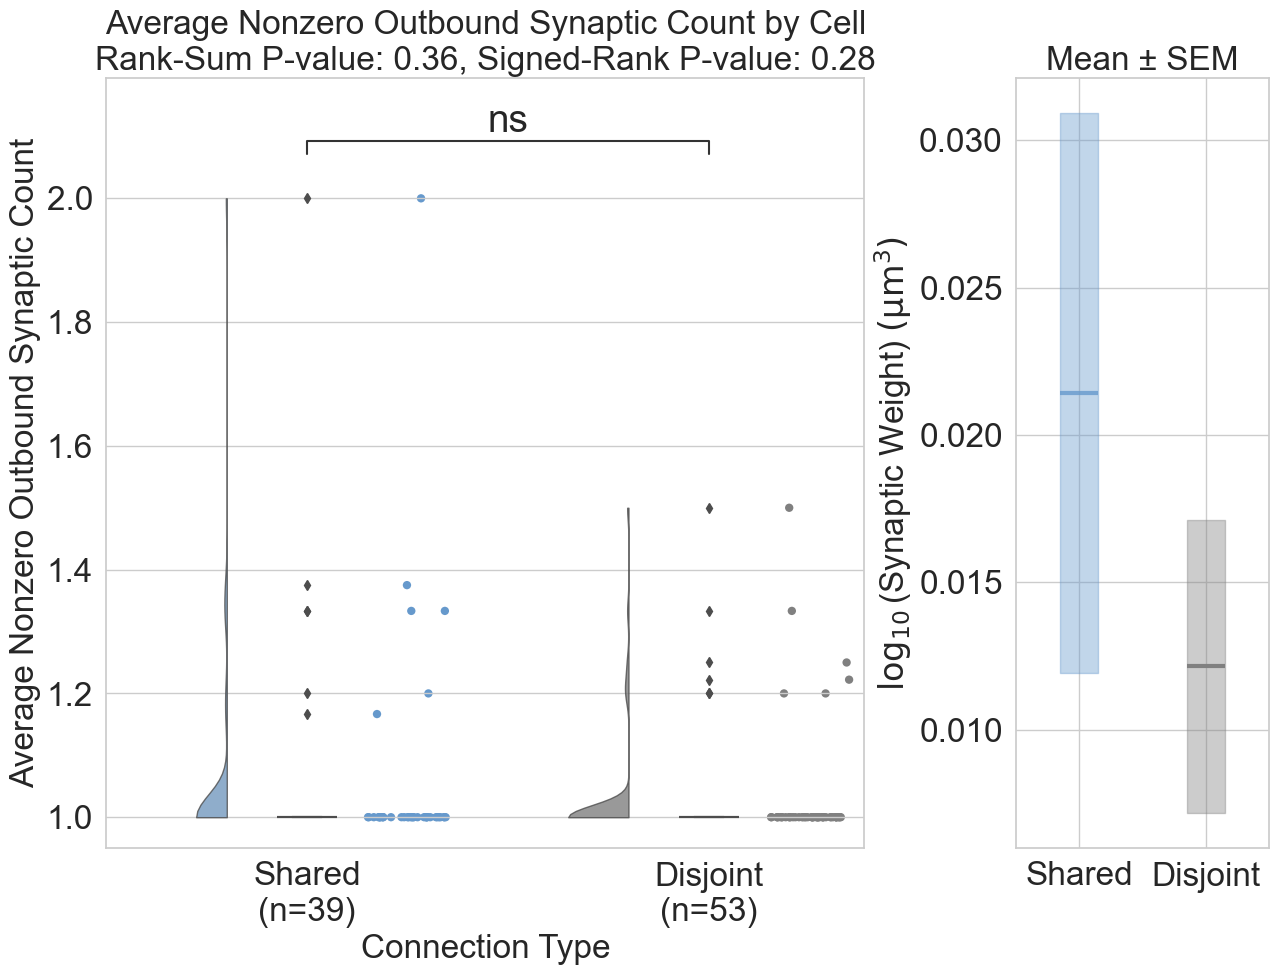

In [19]:
ranksum_signedrank_two_group_comparison(S_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.4394, P-value: 0.3302
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 13, P-value: 0.2981
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:3.302e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


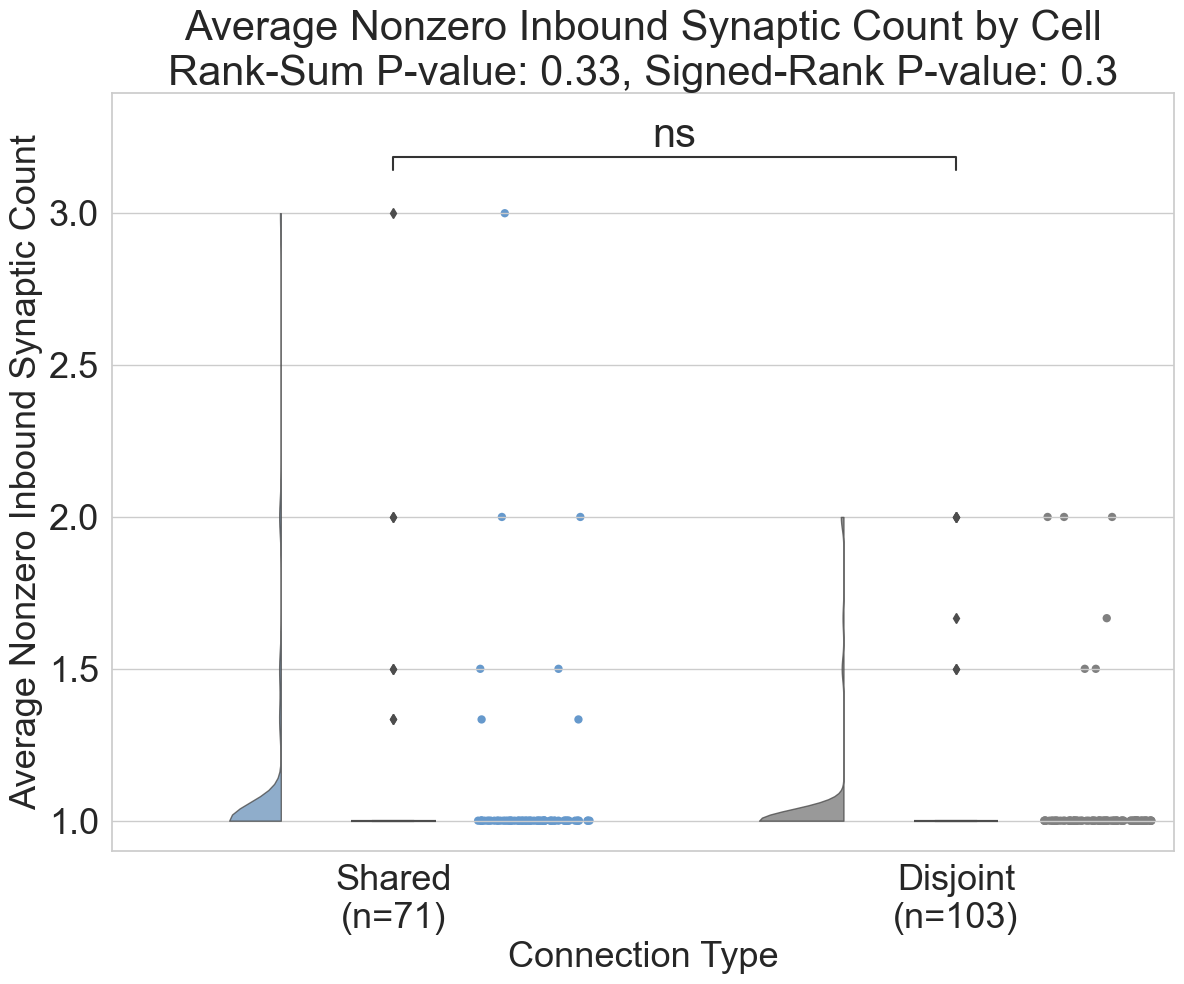

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_8148\3462587406.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:3.302e-01


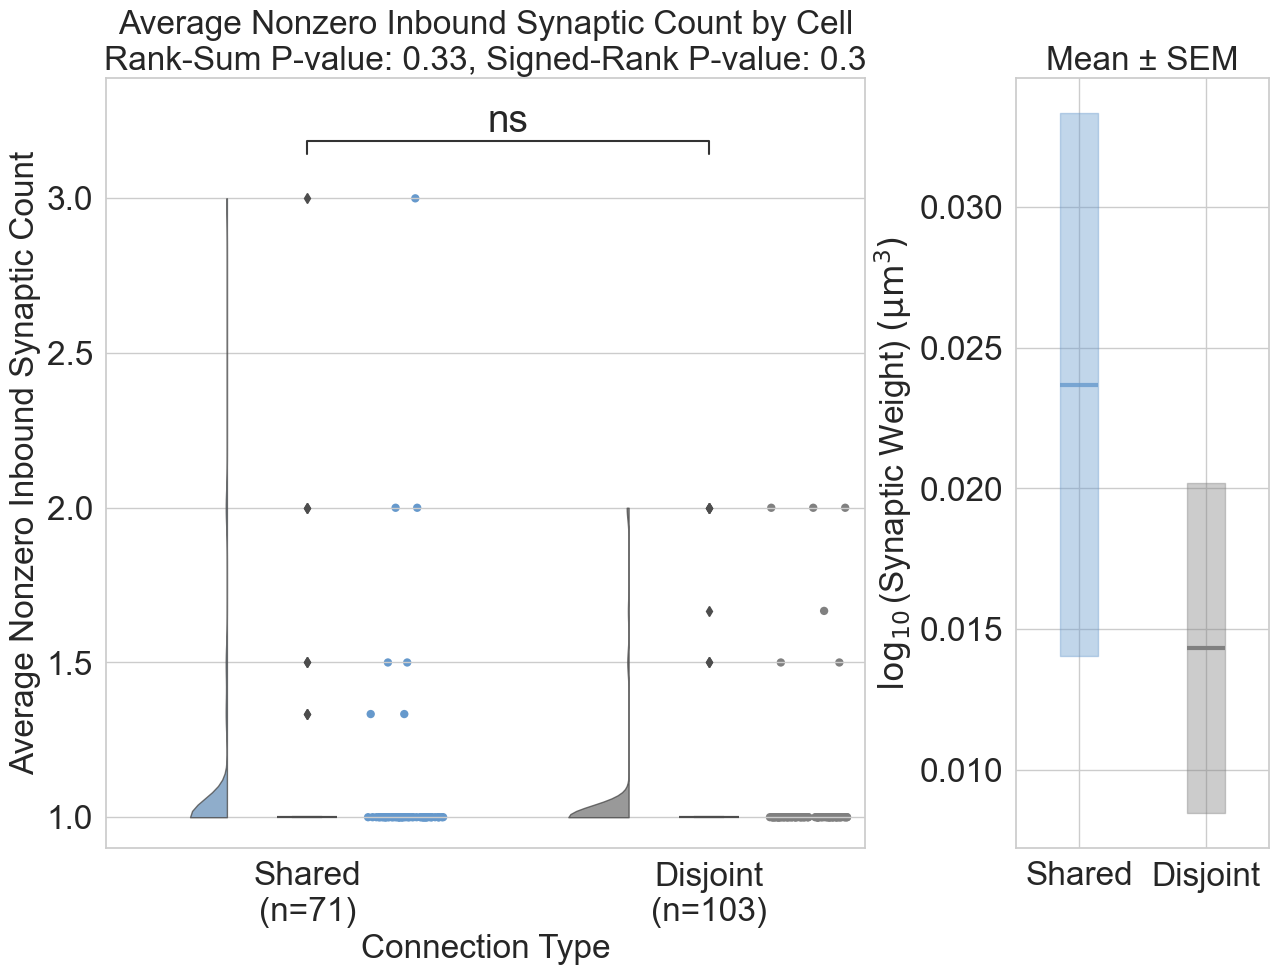

In [20]:
ranksum_signedrank_two_group_comparison(S_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )